In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('C:/Users/nachiket/Downloads/amazon.csv', encoding = "iso-8859-1", parse_dates = ['date'])

In [3]:
data.dtypes

year               int64
state             object
month             object
number           float64
date      datetime64[ns]
dtype: object

#### Display top rows of the dataset

In [4]:
data.head()

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


#### Display last rows of the dataset

In [5]:
data.tail()

,year,state,month,number,date
6449,2012,Tocantins,Dezembro,128.0,2012-01-01
6450,2013,Tocantins,Dezembro,85.0,2013-01-01
6451,2014,Tocantins,Dezembro,223.0,2014-01-01
6452,2015,Tocantins,Dezembro,373.0,2015-01-01
6453,2016,Tocantins,Dezembro,119.0,2016-01-01


#### Find shape of our dataset 

In [6]:
data.shape

(6454, 5)

In [7]:
print("Number of rows:",data.shape[0])
print("Number of columns:",data.shape[1])

Number of rows: 6454
Number of columns: 5


#### Getting information about dataset like total number of rows and columns

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   year    6454 non-null   int64         
 1   state   6454 non-null   object        
 2   month   6454 non-null   object        
 3   number  6454 non-null   float64       
 4   date    6454 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 252.2+ KB


#### Check for duplicate data for drop them

In [9]:
dup_data = data.duplicated().any()

In [10]:
print("Are there any duplicated values in the data", dup_data)

Are there any duplicated values in the data True


In [11]:
data = data.drop_duplicates()

In [12]:
data.shape

(6422, 5)

In [13]:
6454-6422

32

#### Check null values in the dataset

In [14]:
data.isnull().sum()

year      0
state     0
month     0
number    0
date      0
dtype: int64

#### Get overall statistics about the dataframe

In [15]:
data.describe()

,year,number,date
count,6422.000000,6422.000000,6422
mean,2007.490969,108.815178,2007-06-29 10:46:40.622859008
min,1998.000000,0.000000,1998-01-01 00:00:00
25%,2003.000000,3.000000,2003-01-01 00:00:00
50%,2007.000000,24.497000,2007-01-01 00:00:00
75%,2012.000000,114.000000,2012-01-01 00:00:00
max,2017.000000,998.000000,2017-01-01 00:00:00
std,5.731806,191.142482,NaN


In [16]:
data.describe(include = 'all')

,year,state,month,number,date
count,6422.000000,6422,6422,6422.000000,6422
unique,NaN,23,12,NaN,NaN
top,NaN,Rio,Setembro,NaN,NaN
freq,NaN,697,540,NaN,NaN
mean,2007.490969,NaN,NaN,108.815178,2007-06-29 10:46:40.622859008
min,1998.000000,NaN,NaN,0.000000,1998-01-01 00:00:00
25%,2003.000000,NaN,NaN,3.000000,2003-01-01 00:00:00
50%,2007.000000,NaN,NaN,24.497000,2007-01-01 00:00:00
75%,2012.000000,NaN,NaN,114.000000,2012-01-01 00:00:00
max,2017.000000,NaN,NaN,998.000000,2017-01-01 00:00:00


#### Rename month names to English

In [17]:
data['month_new'] = data['month'].map({ 'Janeiro':'jan',
                                        'Fevereiro':'feb',
                                        'Marco':'march',
                                        'Abril':'april',
                                        'Maio':'may',
                                        'Junho':'jun',
                                        'Julho':'july',
                                        'Agosto':'auguest',
                                        'Setembro':'sep',
                                        'Outubro':'oct',
                                        'Novembro':'nov',
                                        'Dezembro':'dec',
                                      })

In [18]:
data.head()

,year,state,month,number,date,month_new
0,1998,Acre,Janeiro,0.0,1998-01-01,jan
1,1999,Acre,Janeiro,0.0,1999-01-01,jan
2,2000,Acre,Janeiro,0.0,2000-01-01,jan
3,2001,Acre,Janeiro,0.0,2001-01-01,jan
4,2002,Acre,Janeiro,0.0,2002-01-01,jan


#### Total number of fires registered

In [19]:
data.shape

(6422, 6)

#### In which month maximum number of forest fires were reported?

In [20]:
data.columns

Index(['year', 'state', 'month', 'number', 'date', 'month_new'], dtype='object')

In [21]:
data1 = data.groupby('month_new')['number'].sum().reset_index()
data1

,month_new,number
0,april,28184.770
1,auguest,88050.435
2,dec,57535.480
3,feb,30839.050
4,jan,47681.844
5,july,92319.113
6,jun,55997.675
7,may,34725.363
8,nov,85508.054
9,oct,88681.579


<Axes: xlabel='month_new', ylabel='number'>

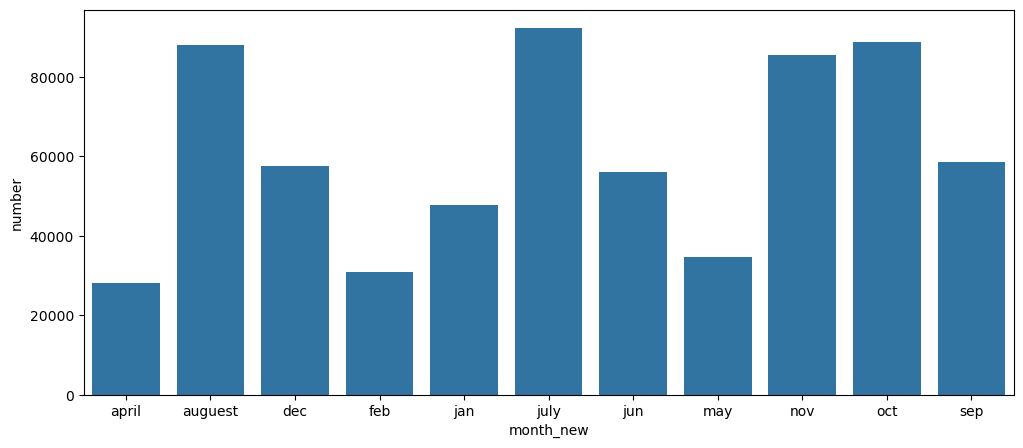

In [22]:
plt.figure(figsize = (12,5))
sns.barplot(x= "month_new", y= "number", data = data1)

#### In which year maximum number of forest fires were reported?

In [23]:
data2 = data.groupby('year')['number'].sum().reset_index()
data2

,year,number
0,1998,20013.971
1,1999,26882.821
2,2000,27351.251
3,2001,29054.612
4,2002,37390.600
5,2003,42760.674
6,2004,38450.163
7,2005,35004.965
8,2006,33824.161
9,2007,33028.413


<Axes: xlabel='year', ylabel='number'>

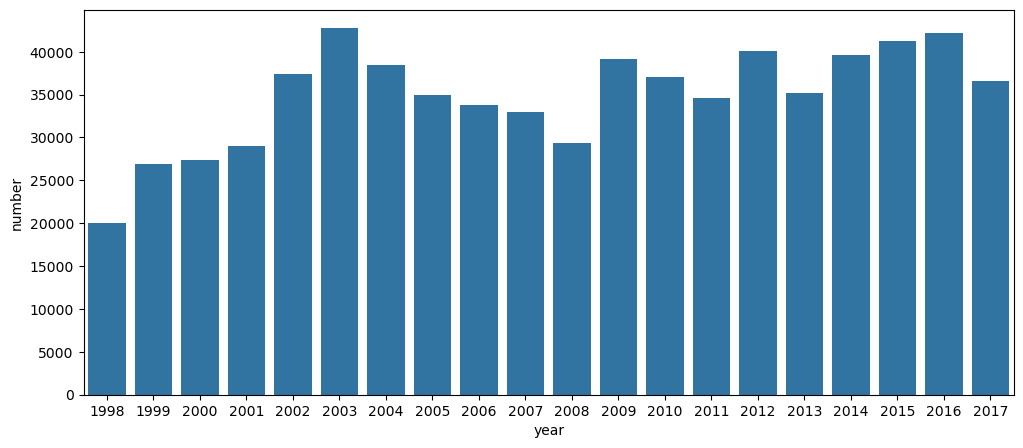

In [24]:
plt.figure(figsize = (12,5))
sns.barplot(x= "year", y= "number", data = data2)

#### In which state maximum number of forest fires were reported?

In [25]:
data.columns

Index(['year', 'state', 'month', 'number', 'date', 'month_new'], dtype='object')

In [26]:
data3 = data.groupby('state')['number'].sum().reset_index()
data3

,state,number
0,Acre,18464.030
1,Alagoas,4606.000
2,Amapa,21831.576
3,Amazonas,30650.129
4,Bahia,44746.226
5,Ceara,30428.063
6,Distrito Federal,3561.000
7,Espirito Santo,6546.000
8,Goias,37695.520
9,Maranhao,25129.131


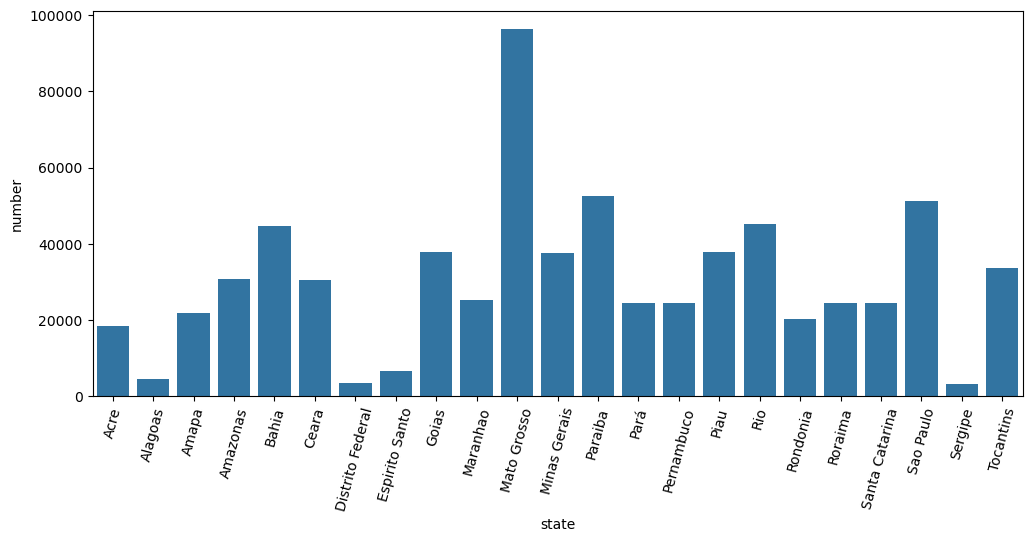

In [27]:
plt.figure(figsize = (12,5))
sns.barplot(x= "state", y= "number", data = data3)
plt.xticks(rotation = 75)
plt.show()

#### Find total number of fires were reported in Amazonas

In [28]:
data[data['state'] == 'Amazonas']['number'].sum()

np.float64(30650.129)

#### Display number of fires were reported in Amazonas (Year Wise)

In [29]:
data4 = data[data['state'] == "Amazonas"]
data5 = data4.groupby('year')['number'].sum().reset_index()
data5

,year,number
0,1998,946.000
1,1999,1061.000
2,2000,853.000
3,2001,1297.000
4,2002,2852.000
5,2003,1524.268
6,2004,2298.207
7,2005,1657.128
8,2006,997.640
9,2007,589.601


<Axes: xlabel='year', ylabel='number'>

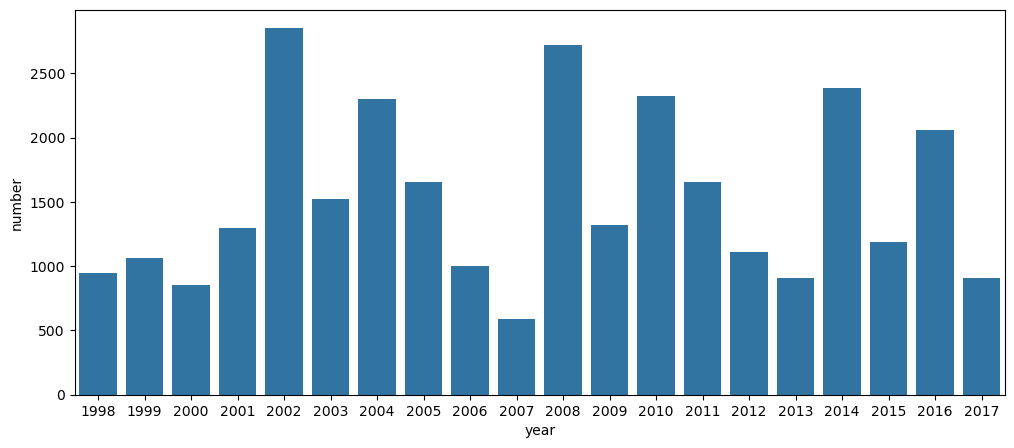

In [30]:
plt.figure(figsize = (12,5))
sns.barplot(x = "year", y = "number", data = data5)

#### Display number of fires were reported in Amazonas (Day Wise)

In [31]:
data6 = data[data['state'] == "Amazonas"]

In [32]:
day = data6.groupby(data6['date'].dt.dayofweek)['number'].sum()

In [33]:
day

date
0    1886.601
1    6474.217
2    3910.177
3    5754.802
4    5446.480
5    4162.666
6    3015.186
Name: number, dtype: float64

In [34]:
day = data6.groupby(data6['date'].dt.dayofweek)['number'].sum()

import calendar

day = [calendar.day_name[x] for x in range(0,7)]

day 

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [35]:
day = data6.groupby(data6['date'].dt.dayofweek)['number'].sum()

import calendar

day.index = [calendar.day_name[x] for x in range(0,7)]
day 

Monday       1886.601
Tuesday      6474.217
Wednesday    3910.177
Thursday     5754.802
Friday       5446.480
Saturday     4162.666
Sunday       3015.186
Name: number, dtype: float64

In [36]:
day = data6.groupby(data6['date'].dt.dayofweek)['number'].sum()

import calendar

day.index = [calendar.day_name[x] for x in range(0,7)]
day = day.reset_index()

day

,index,number
0,Monday,1886.601
1,Tuesday,6474.217
2,Wednesday,3910.177
3,Thursday,5754.802
4,Friday,5446.480
5,Saturday,4162.666
6,Sunday,3015.186


<Axes: xlabel='index', ylabel='number'>

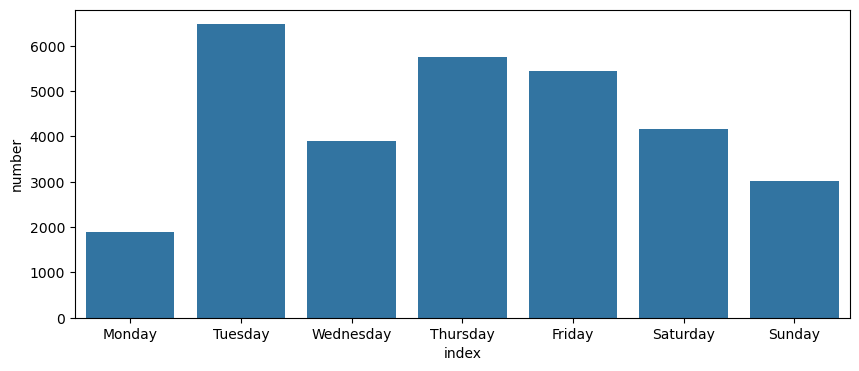

In [37]:
plt.figure(figsize = (10,4))
sns.barplot(x ="index", y= "number", data = day)

#### Find total number of fires were reported in 2015 and visualize data based on each 'Month'

In [38]:
data.columns

Index(['year', 'state', 'month', 'number', 'date', 'month_new'], dtype='object')

In [39]:
fire = data[data['year'] == 2015].groupby('month_new')['number'].sum().reset_index()

In [40]:
fire

,month_new,number
0,april,2573.000
1,auguest,4363.125
2,dec,4088.522
3,feb,2309.000
4,jan,4635.000
5,july,4364.392
6,jun,3260.552
7,may,2384.000
8,nov,4034.518
9,oct,4499.525


<Axes: xlabel='month_new', ylabel='number'>

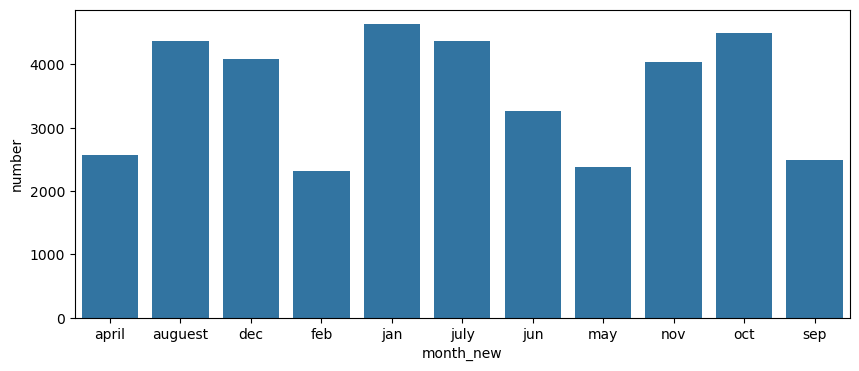

In [41]:
plt.figure(figsize = (10,4))
sns.barplot(x= "month_new", y= "number", data = fire)

#### Find average number of fires were reported from highest to lowest (State wise)

In [42]:
data.columns

Index(['year', 'state', 'month', 'number', 'date', 'month_new'], dtype='object')

In [43]:
data8 = data.groupby('state')['number'].mean().sort_values(ascending = False).reset_index()

In [44]:
data8

,state,number
0,Sao Paulo,213.896226
1,Mato Grosso,203.479975
2,Bahia,187.222703
3,Piau,158.174674
4,Goias,157.721841
5,Minas Gerais,156.800243
6,Tocantins,141.037176
7,Amazonas,128.243218
8,Ceara,127.314071
9,Paraiba,111.073979


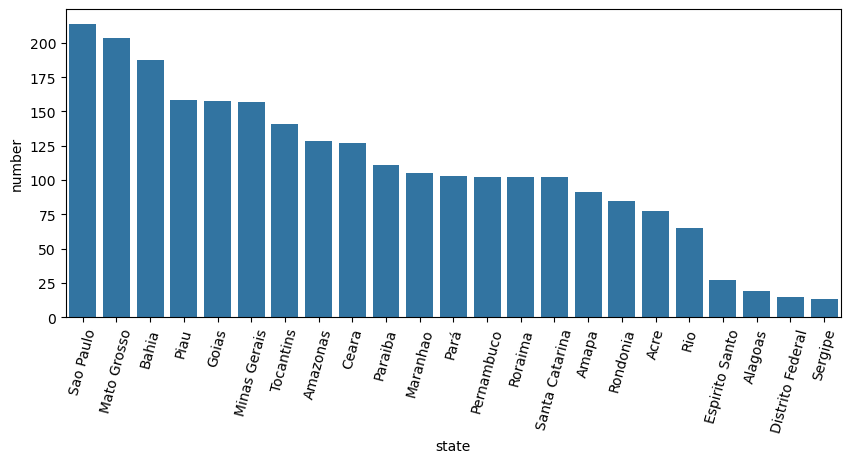

In [45]:
plt.figure(figsize = (10,4))
sns.barplot(x= "state", y= "number", data = data8)
plt.xticks(rotation = 75)
plt.show()

#### To find the state names where fires were reported in 'dec' month

In [46]:
data[data['month_new'] == 'dec']['state'].unique()

array(['Acre', 'Alagoas', 'Amapa', 'Amazonas', 'Bahia', 'Ceara',
       'Distrito Federal', 'Espirito Santo', 'Goias', 'Maranhao',
       'Mato Grosso', 'Minas Gerais', 'Pará', 'Paraiba', 'Pernambuco',
       'Piau', 'Rio', 'Rondonia', 'Roraima', 'Santa Catarina',
       'Sao Paulo', 'Sergipe', 'Tocantins'], dtype=object)